In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(11610, 8) (5160, 8) (3870, 8)


In [3]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

Epoch: 1/1000, Train Loss: 2.106, Train Metric: 0.975, Valid Metric: 0.597, Learning Rate: 0.633, Time: 0.67s
	Checkpoint, valid metric: 0.597
Epoch: 2/1000, Train Loss: 0.794, Train Metric: 0.645, Valid Metric: 0.571, Learning Rate: 0.459, Time: 0.7s
	Checkpoint, valid metric: 0.571
Epoch: 3/1000, Train Loss: 0.473, Train Metric: 0.502, Valid Metric: 0.474, Learning Rate: 0.242, Time: 0.72s
	Checkpoint, valid metric: 0.474
Epoch: 4/1000, Train Loss: 0.441, Train Metric: 0.449, Valid Metric: 0.42, Learning Rate: 0.068, Time: 0.76s
	Checkpoint, valid metric: 0.420
Epoch: 5/1000, Train Loss: 0.361, Train Metric: 0.424, Valid Metric: 0.412, Learning Rate: 0.700, Time: 0.75s
	Checkpoint, valid metric: 0.412
Epoch: 6/1000, Train Loss: 0.677, Train Metric: 0.627, Valid Metric: 0.434, Learning Rate: 0.683, Time: 0.73s
Epoch: 7/1000, Train Loss: 0.509, Train Metric: 0.521, Valid Metric: 0.433, Learning Rate: 0.633, Time: 0.86s
Epoch: 8/1000, Train Loss: 0.442, Train Metric: 0.486, Valid Metric

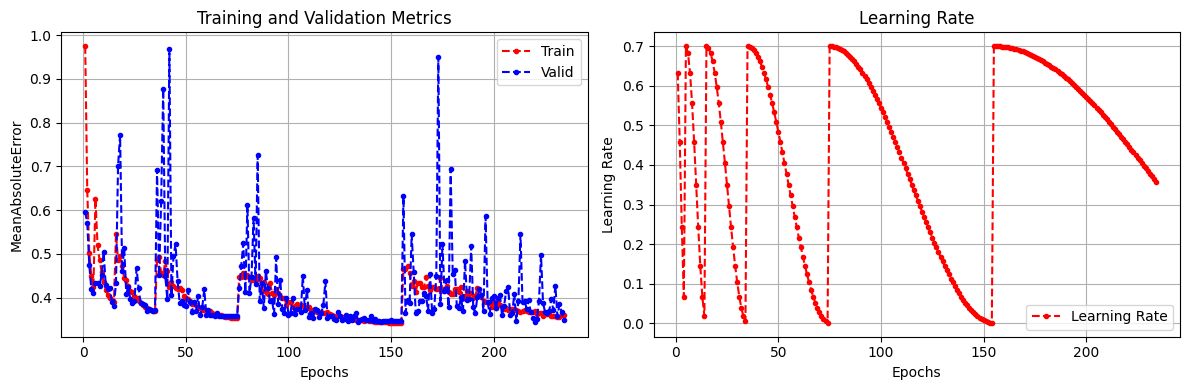

In [4]:
from custom_utils import train, plot_history

# model = nn.Sequential(
# 	# nn.BatchNorm1d(8),
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.LeakyReLU(),
# 	# nn.BatchNorm1d(30),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.LeakyReLU(),
# 	# nn.BatchNorm1d(50),
# 	nn.Linear(in_features=50, out_features=1),
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(
    	self, 
     	n_features, 
      	hidden_dims=[16, 24, 16, 8],
		use_batchnorm=False,
		dropout_rate=None
    ):
		super().__init__()
		layers = []
		for i, hidden_dim in enumerate(hidden_dims):
			layers.append(nn.Linear(
       			in_features=n_features if i==0 else hidden_dims[i-1], 
          		out_features=hidden_dim, 
            	bias=False if use_batchnorm else True
			))
			layers.append(nn.LeakyReLU())
			if use_batchnorm:
				layers.append(nn.BatchNorm1d(hidden_dim))
			if dropout_rate is not None:
				layers.append(nn.Dropout(dropout_rate))
		layers.append(nn.Linear(
      		in_features=hidden_dims[-1], 
          	out_features=1,
            bias=False if use_batchnorm else True
		))
		self.sequential = nn.Sequential(*layers)
               
	def forward(self, X):
		y = self.sequential(X)
		return y

hidden_dims = [16, 24, 16, 8]
model = PriceRegressor(
    n_features=8, 
    hidden_dims=[16, 24, 16, 8],
    # dropout_rate=0.1
).to(device)

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias) 
model.apply(use_he_init)

learning_rate = 0.7
n_epochs = 1000
patience = n_epochs // 10
warmup_epochs = patience // 2

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
# optimizer = torch.optim.AdamW(params=model.parameters(), lr=learning_rate)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=warmup_epochs)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=0.001)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	scheduler=scheduler, 
	patience=patience,
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

In [8]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.364


In [9]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_features": 8,
        "hidden_dims": [16, 24, 16, 8],
        "use_batchnorm": False,
        "dropout_rate": None
    }
}
torch.save(model_data, "fashion_mnist_model.pt")

loaded_data = torch.load("fashion_mnist_model.pt", weights_only=True)
new_model = PriceRegressor(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model

PriceRegressor(
  (sequential): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=16, out_features=24, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=24, out_features=16, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [10]:
sum([param.numel() for param in model.parameters()])

1097